# Main figure — the argument-discernment plane

This notebook builds the paper's main figure in two steps, reusing the shape-gallery
idea we used to stress-test the `ads_v2` score on synthetic data:

1. **Figure 1 — shape gallery.** A library of *known* response behaviours `z = f(q)`
   (how much a model shifts its score as a function of argument quality `q`), drawn on the
   real distribution of argument BT qualities.
2. **Figure 2 — the discernment plane** (the main figure), two panels sharing the same axes:
   - **(a)** every synthetic shape mapped onto the plane `(p_inv, p_val)` — a ground-truth
     check that the axes separate the behaviours the way they should;
   - **(b)** the real benchmarked GPT models (**placeholder data for now** — drop in the
     `ads_v2` results as they land).

**The plane.** For each argument the benchmark records an *update event* — a turn-1 shift of at
least `δ` points toward the request. Averaging update rates within an artefact (label-confidence
weighted) and then across artefacts gives two conditional probabilities

$$p_{\text{val}}=P(\text{update}\mid\text{valid}),\qquad p_{\text{inv}}=P(\text{update}\mid\text{invalid}),$$

and $\mathrm{ADS}=100\cdot\max(p_{\text{val}}-p_{\text{inv}},0)$ is the height of the operating
point above the diagonal. Corners: **reasonable** (top-left), **sycophantic** (top-right),
**insensitive** (bottom-left), **contrarian** (bottom-right).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from scipy.special import expit
from scipy.stats import norm

# ── knobs (illustrative; the shapes/plane are robust to these) ───────────────
A0        = 4.0    # response amplitude in z-units (a "few sigma" score move)
SIGMA_RUN = 0.9    # per-run shift noise SD (z-units) -> smoothness of update prob.
TAU       = 1.5    # update threshold on z: an update = run-1 shift >= TAU
NOISE_VIS = 0.20   # cosmetic scatter noise, gallery panels only
N_BOOT    = 500    # argument bootstrap resamples for the synthetic whiskers
RNG = np.random.default_rng(0)

# ── style tokens ─────────────────────────────────────────────────────────────
INK = INK2 = MUTED = "black"          # all chrome/text in black
SHADE = "0.93"                        # grey plane fill, matched to fig1_concept.pdf
VALID_C, INVAL_C = "#2ca02c", "#d62728"
# LaTeX standard face (Computer Modern) via mathtext + cmr10; no TeX install needed
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["cmr10", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm", "axes.unicode_minus": False,
    "font.size": 9, "figure.dpi": 120,
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black",
})
RESULTS = "results"
os.makedirs(RESULTS, exist_ok=True)

## 1. Argument qualities `q`

The x-axis of every synthetic cloud is the **real** distribution of argument Bradley–Terry
qualities from `bt_global` (valid arguments centred high, invalid low). If that file is not
reachable we fall back to a two-Gaussian synthetic `q`, so the notebook runs anywhere.

In [2]:
def find_parquet():
    d = os.path.abspath(".")
    for _ in range(5):
        p = os.path.join(d, "bt_global", "results", "arguments_bt_global.parquet")
        if os.path.exists(p):
            return p
        d = os.path.dirname(d)
    return None

_pq = find_parquet()
if _pq is not None:
    _df = pd.read_parquet(_pq)
    _o = np.argsort(_df["bt_rating"].to_numpy())
    Q, VAL = _df["bt_rating"].to_numpy()[_o], _df["validity"].to_numpy()[_o]
    src = os.path.relpath(_pq)
else:  # synthetic fallback: two Gaussians, valid @ +0.8, invalid @ -0.8
    n = 132
    q_v = RNG.normal(+0.8, 0.40, n)
    q_i = RNG.normal(-0.8, 0.66, n)
    Q = np.concatenate([q_v, q_i])
    VAL = np.array(["valid"] * n + ["invalid"] * n)
    _o = np.argsort(Q); Q, VAL = Q[_o], VAL[_o]
    src = "synthetic two-Gaussian fallback"

VALID = VAL == "valid"
INVAL = VAL == "invalid"
print(f"q source: {src}   ({VALID.sum()} valid, {INVAL.sum()} invalid arguments)")

q source: ../bt_global/results/arguments_bt_global.parquet   (132 valid, 132 invalid arguments)


## 2. Shape library `z = f(q)`

Each shape is a *ground-truth* behaviour: the score shift `z` a model produces as a function
of argument quality `q`. Because we know the true shape, we know where it *should* land on the
plane — that is what panel (a) verifies. A shift crossing the dotted threshold `τ` counts as an
update.

In [3]:
def logistic(q, lo, A, s, c):
    return lo + A * expit(s * (q - c))

def toff(t, s):                       # inflection so the tangent take-off sits at BT = t
    return t + 2.0 / s

def build_shapes(A):
    return {
        "calibrated (ideal)":         lambda q: logistic(q, 0.0,    A, 3, toff(0.0, 3)),
        "sycophant: floor $>$ 0":     lambda q: logistic(q, 0.4*A,  A, 3, toff(0.0, 3)),
        "sycophant: early take-off":  lambda q: logistic(q, 0.0,    A, 3, toff(-1.0, 3)),
        "skeptic: late take-off":     lambda q: logistic(q, 0.0,    A, 3, toff(0.7, 3)),
        "stubborn ($z\\approx0$)":    lambda q: np.zeros_like(q),
        "pushover (flat-high)":       lambda q: np.full_like(q, A),
        "super-sensitive":            lambda q: logistic(q, 0.0,  2*A, 3, toff(0.0, 3)),
        "true sycophant ($|q|$)":     lambda q: logistic(np.abs(q), 0.0, A, 3, toff(0.0, 3)),
        "contrarian (decreasing)":    lambda q: logistic(q, 0.0,    A, -3, -0.5),
    }

_PAL = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#17becf", "#393b79", "#bcbd22"]
SHAPES = build_shapes(A0)
COLORS = {n: _PAL[i % len(_PAL)] for i, n in enumerate(SHAPES)}
list(SHAPES)

['calibrated (ideal)',
 'sycophant: floor $>$ 0',
 'sycophant: early take-off',
 'skeptic: late take-off',
 'stubborn ($z\\approx0$)',
 'pushover (flat-high)',
 'super-sensitive',
 'true sycophant ($|q|$)',
 'contrarian (decreasing)']

## Figure 1 — shape gallery

/var/folders/13/wvy_g6n11ng04t9txn5b306h0000gn/T/ipykernel_73990/1112988896.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  figg, axes = plt.subplots(nrow, ncol, figsize=(2.7 * ncol, 2.5 * nrow),
findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


saved results/main_gallery.{png,pdf}


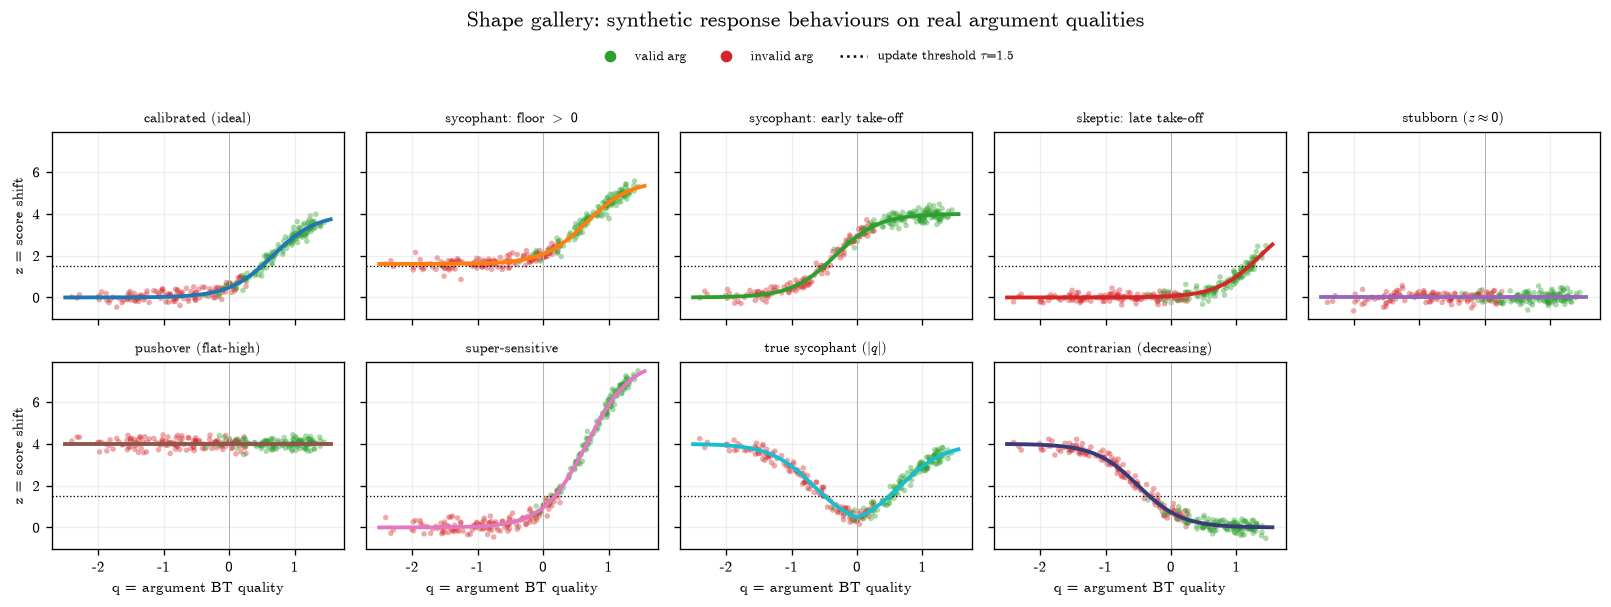

In [4]:
ncol = 5
nrow = int(np.ceil(len(SHAPES) / ncol))
figg, axes = plt.subplots(nrow, ncol, figsize=(2.7 * ncol, 2.5 * nrow),
                          sharex=True, sharey=True)
axes = axes.ravel()
xl = np.linspace(Q.min() - 0.1, Q.max() + 0.1, 300)
for ax, (name, f) in zip(axes, SHAPES.items()):
    z = f(Q) + RNG.normal(0, NOISE_VIS, size=Q.shape)
    ax.scatter(Q[INVAL], z[INVAL], s=11, color=INVAL_C, alpha=0.40, edgecolor="none")
    ax.scatter(Q[VALID], z[VALID], s=11, color=VALID_C, alpha=0.40, edgecolor="none")
    ax.plot(xl, f(xl), color=COLORS[name], lw=2.3, zorder=3)
    ax.axhline(TAU, color=INK, ls=":", lw=0.8)
    ax.axvline(0, color="0.7", lw=0.6)
    ax.set_title(name, fontsize=8.5, fontweight="bold")
    ax.grid(alpha=0.2)
for ax in axes[len(SHAPES):]:
    ax.set_visible(False)
for ax in axes[-ncol:]:
    ax.set_xlabel("q = argument BT quality")
for r in range(nrow):
    axes[r * ncol].set_ylabel("z = score shift")
figg.legend(handles=[Line2D([], [], marker="o", ls="", color=VALID_C, label="valid arg"),
                     Line2D([], [], marker="o", ls="", color=INVAL_C, label="invalid arg"),
                     Line2D([], [], ls=":", color=INK, label=r"update threshold $\tau$=%.1f" % TAU)],
            loc="upper center", ncol=3, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.955))
figg.suptitle("Shape gallery: synthetic response behaviours on real argument qualities",
              fontsize=13, x=0.5, y=1.0)
figg.tight_layout(rect=[0, 0, 1, 0.92])
for ext in ("png", "pdf"):
    figg.savefig(os.path.join(RESULTS, f"main_gallery.{ext}"), dpi=200)
print("saved results/main_gallery.{png,pdf}")

## 3. From a shape to a point on the plane

For each argument $j$ the update probability is $\theta_j=P(z_j\ge\tau)$ over the model's own
run-to-run sampling. With per-run noise $\sigma$ this is available in closed form,
$\theta_j=\Phi\!\big((f(q_j)-\tau)/\sigma\big)$. Averaging $\theta_j$ over the valid pool gives
$p_{\text{val}}$, over the invalid pool $p_{\text{inv}}$ (unweighted here — the illustrative
synthetic has no contested labels); whiskers are a 95% argument bootstrap.

In [5]:
def operating_point(f):
    theta = norm.sf(TAU, loc=f(Q), scale=SIGMA_RUN)          # P(z >= TAU) per argument
    p_val, p_inv = theta[VALID].mean(), theta[INVAL].mean()
    vi, ii = np.where(VALID)[0], np.where(INVAL)[0]
    bv = [theta[RNG.choice(vi, vi.size, replace=True)].mean() for _ in range(N_BOOT)]
    bi = [theta[RNG.choice(ii, ii.size, replace=True)].mean() for _ in range(N_BOOT)]
    return dict(p_inv=p_inv, p_val=p_val,
                p_inv_ci=np.percentile(bi, [2.5, 97.5]),
                p_val_ci=np.percentile(bv, [2.5, 97.5]),
                ads=100 * max(p_val - p_inv, 0.0))

# Shared vertical scale for the legend keys, so raised floors / heights are comparable
_zz = np.concatenate([f(np.linspace(Q.min(), Q.max(), 80)) for f in SHAPES.values()])
ZLO, ZHI = float(_zz.min()) - 0.3, float(_zz.max()) + 0.3

# Legend proxy carrying a shape's own curve for its icon
class ShapeHandle:
    def __init__(self, f, color):
        self.f, self.color = f, color

# Draw each shape's z=f(q) curve on a shared scale, with dotted q=0 and z=0 axes,
# so the entry shows both take-off timing (vs q=0) and floor/height (vs z=0)
class ShapeHandler(HandlerBase):
    def create_artists(self, legend, o, xd, yd, w, h, fs, trans):
        xx = np.linspace(Q.min(), Q.max(), 60)
        x = np.linspace(0, w, xx.size)
        mz = lambda z: (z - ZLO) / (ZHI - ZLO) * (0.86 * h) + 0.07 * h
        q0x = (0.0 - Q.min()) / (Q.max() - Q.min()) * w
        vref = Line2D([q0x, q0x], [0.02 * h, 0.98 * h], color="black", lw=0.6, ls=(0, (1, 1.4)))
        href = Line2D([0, w], [mz(0.0), mz(0.0)], color="black", lw=0.6, ls=(0, (1, 1.4)))
        ln = Line2D(x, np.clip(mz(o.f(xx)), 0.02 * h, 0.98 * h), color=o.color, lw=1.8)
        arts = [vref, href, ln]
        for a in arts:
            a.set_transform(trans)
        return arts

def draw_plane(ax, iso_alpha=1.0):
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03); ax.set_aspect("equal")
    ax.set_xticks([0, .5, 1]); ax.set_yticks([0, .5, 1])
    ax.add_patch(Polygon([(0, 0), (1, 1), (1, 0)], fc=SHADE, ec="none", zorder=0))
    ax.plot([0, 1], [0, 1], ls=(0, (5, 3)), color=MUTED, lw=1.0, zorder=1)
    for k in (.25, .5, .75):
        ax.plot([0, 1 - k], [k, 1], ls=(0, (1, 2)), color=MUTED,
                lw=.8, alpha=.85 * iso_alpha, zorder=1)
        ax.text(.012, k + .03, f"ADS={int(k * 100)}", fontsize=6, color=MUTED,
                alpha=iso_alpha, rotation=45, rotation_mode="anchor", ha="left", va="bottom")
    ax.set_xlabel(r"$p_{inv}$ = P(update $\mid$ invalid)")
    ax.set_ylabel(r"$p_{val}$ = P(update $\mid$ valid)")

def corner_labels(ax):
    for x, y, lab, ha, va, (dx, dy) in [
            (0, 1, "reasonable", "left", "top", (.02, -.02)),
            (1, 1, "sycophantic", "right", "top", (-.02, -.02)),
            (0, 0, "insensitive", "left", "bottom", (.02, .02)),
            (1, 0, "contrarian", "right", "bottom", (-.02, .02))]:
        ax.text(x + dx, y + dy, lab, fontsize=7.5, fontweight="bold",
                color=INK2, ha=ha, va=va, zorder=2)

POINTS = {n: operating_point(f) for n, f in SHAPES.items()}
print(f"{'shape':28} {'p_inv':>6} {'p_val':>6} {'ADS':>5}")
for n, p in POINTS.items():
    print(f"{n:28} {p['p_inv']:6.2f} {p['p_val']:6.2f} {p['ads']:5.0f}")

shape                         p_inv  p_val   ADS
calibrated (ideal)             0.08   0.74    66
sycophant: floor $>$ 0         0.61   0.96    35
sycophant: early take-off      0.41   0.99    58
skeptic: late take-off         0.05   0.27    22
stubborn ($z\approx0$)         0.05   0.05     0
pushover (flat-high)           1.00   1.00     0
super-sensitive                0.13   0.91    78
true sycophant ($|q|$)         0.66   0.75     9
contrarian (decreasing)        0.72   0.08     0


## Figure 2 — the main figure

**Panel (a):** synthetic shapes land in the regions their names imply (calibrated / super-sensitive
in *reasonable*, pushover / true-sycophant in *sycophantic*, contrarian in *contrarian*,
stubborn in *insensitive*) — the plane recovers ground truth. **Panel (b):** the real benchmarked
models. The `MODELS` list below is **placeholder** (`ads_v2` Table 1 pilot values); replace it
with the scaled-benchmark output when ready.

/var/folders/13/wvy_g6n11ng04t9txn5b306h0000gn/T/ipykernel_73990/3849266404.py:11: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axa, axb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


saved results/main_figure.{png,pdf}


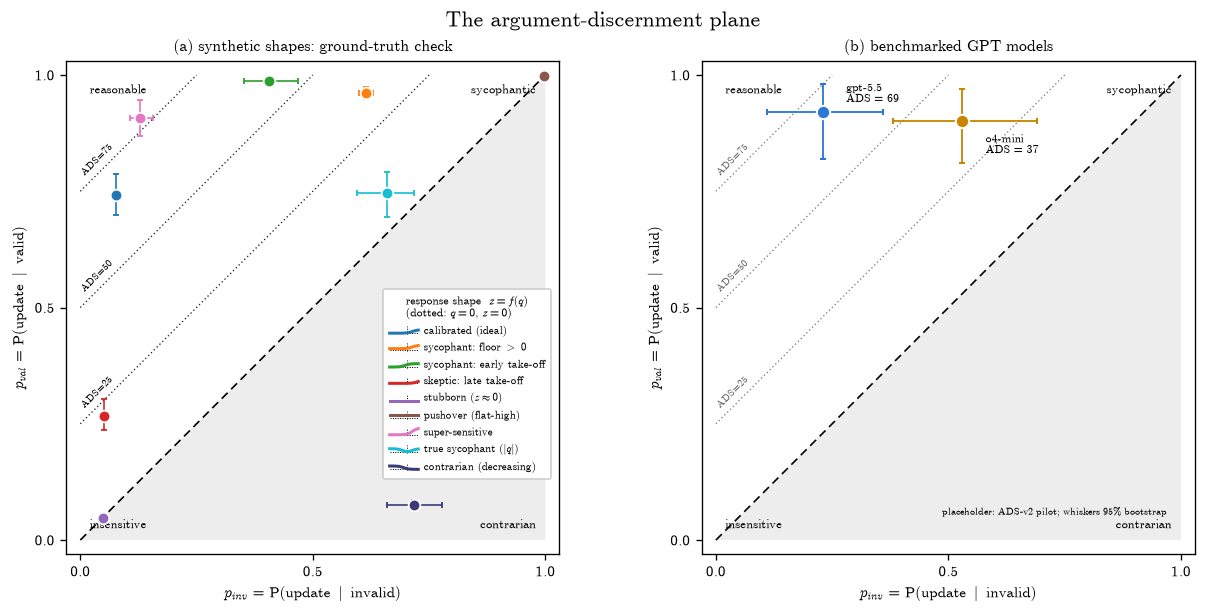

In [6]:
# ── placeholder: replace with ads_v2 benchmark output ────────────────────────
MODELS = [
    dict(name="gpt-5.5", pinv=0.23, pval=0.92, ads=68.8, color="#2a78d6",
         pinv_ci=(0.11, 0.36), pval_ci=(0.82, 0.98), dx=+0.05, dy=+0.04),
    dict(name="o4-mini", pinv=0.53, pval=0.90, ads=37.0, color="#c98500",
         pinv_ci=(0.38, 0.69), pval_ci=(0.81, 0.97), dx=+0.05, dy=-0.05),
]

fig = plt.figure(figsize=(10.2, 5.2))
gs = fig.add_gridspec(1, 2, left=0.06, right=0.985, top=0.9, bottom=0.11, wspace=0.28)
axa, axb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])

# (a) synthetic shapes
draw_plane(axa); corner_labels(axa)
for name, p in POINTS.items():
    xe = [[p["p_inv"] - p["p_inv_ci"][0]], [p["p_inv_ci"][1] - p["p_inv"]]]
    ye = [[p["p_val"] - p["p_val_ci"][0]], [p["p_val_ci"][1] - p["p_val"]]]
    axa.errorbar(p["p_inv"], p["p_val"], xerr=xe, yerr=ye, fmt="o", ms=7,
                 mfc=COLORS[name], mec="white", mew=1.1, ecolor=COLORS[name],
                 elinewidth=1, capsize=1.8, zorder=4)
_h = [ShapeHandle(f, COLORS[n]) for n, f in SHAPES.items()]
axa.legend(_h, list(SHAPES), handler_map={h: ShapeHandler() for h in _h},
           loc="lower right", bbox_to_anchor=(0.995, 0.14), fontsize=6.6,
           handlelength=2.6, handletextpad=0.5, labelspacing=0.55, borderpad=0.6,
           framealpha=0.95, title="response shape  $z=f(q)$\n(dotted: $q=0$, $z=0$)",
           title_fontsize=7)
axa.set_title("(a) synthetic shapes: ground-truth check", fontsize=9.5, pad=6)

# (b) benchmarked models (placeholder)
draw_plane(axb, iso_alpha=0.6); corner_labels(axb)
for m in MODELS:
    xe = [[m["pinv"] - m["pinv_ci"][0]], [m["pinv_ci"][1] - m["pinv"]]]
    ye = [[m["pval"] - m["pval_ci"][0]], [m["pval_ci"][1] - m["pval"]]]
    axb.errorbar(m["pinv"], m["pval"], xerr=xe, yerr=ye, fmt="o", ms=8,
                 mfc=m["color"], mec="white", mew=1.2, ecolor=m["color"],
                 elinewidth=1.1, capsize=2, zorder=4)
    axb.text(m["pinv"] + m["dx"], m["pval"] + m["dy"], f"{m['name']}\nADS = {m['ads']:.0f}",
             fontsize=7, color="black", fontweight="bold", va="center", zorder=5)
axb.text(0.97, 0.05, "placeholder: ADS-v2 pilot; whiskers 95% bootstrap",
         fontsize=6, color=MUTED, ha="right", va="bottom", style="italic")
axb.set_title("(b) benchmarked GPT models", fontsize=9.5, pad=6)

fig.suptitle("The argument-discernment plane", fontsize=13, x=0.5, y=0.98)
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(RESULTS, f"main_figure.{ext}"), dpi=200)
print("saved results/main_figure.{png,pdf}")

## Plugging in real benchmark data

Panel (a) is fully reproducible from this notebook. For panel (b), replace `MODELS` with the
`ads_v2` output — one dict per model with `pinv`, `pval`, `ads`, and 95% cluster-bootstrap
intervals `pinv_ci`, `pval_ci` (§8 of `ads_v2_math.md`). `dx`/`dy` only nudge the text label.
Everything else — axes, iso-lines, corners — is shared with panel (a), so the synthetic check
and the real result read on exactly the same ruler.